# Marketing Analytics Project
Selam Mahmud Ali 48015A 

Mokhammad Ali Sheikh Soltani 65865A 

Angela Aldaoud 61102A 

Talha Kose 53509A 

Laura Shulbayeva 51204A 

Salman Askarov 65829A 

Dias Kalyshev 60641A 

Erdem Bakir 65288A

## Conjoint Analysis on Forcetek Jerseys
#### {Order of plots and numbered titles correspond to the numbered chapters in the pdf report submitted}

In [6]:
# reset
rm(list = ls())
cat("\014")
graphics.off()

In [7]:
#used libraries
library(readxl)
library(dplyr)
library(tidyverse)
library(ggplot2)
library(tidyr)
library(readr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ purrr     1.2.1
✔ ggplot2   4.0.2     ✔ readr     2.1.6
✔ lubridate 1.9.5     ✔ tibble    3.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ Matrix::expand()     masks tidyr::expand()
✖ dplyr::filter()      masks stats::filter()
✖ purrr::flatten()     masks rlang::flatten()
✖ purrr::flatten_chr() masks rlang::flatten_chr()
✖ purrr::flatten_dbl() masks rlang::flatten_dbl()
✖ purrr::flatten_int() masks rlang::flatten_int()
✖ purrr::flatten_lgl() masks rlang::flatten_lgl()
✖ purrr::flatten_raw() masks rlang::flatten_raw()
✖ purrr::invoke()      masks rlang::invoke()
✖ dplyr::lag()         masks stats::lag()
✖ Matrix::pack()       masks tidyr::pack()
✖ purrr::splice()      masks rlang::splice()
✖ Matrix::unpack()     masks tidyr::unpack()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [8]:
# --- 1. Load Data ---
# Replace with your actual file name
file_path <- "/Users/selammahmudali/Desktop/conjoint_data.xlsx"

# Read the 'Respondents' sheet
# We skip the first 2 rows because they contain metadata/empty space before the actual header
respondents <- read_excel(file_path, sheet = "Respondents", skip = 2)

# --- 2. Filter Data ---
# Filter for respondents marked as 'Is good for analysis'
df_good <- respondents %>%
  filter(`Is good for analysis` == 1)

# --- 2.1 Filter Out Irrelevant Ages ---
# Identify the Age column name
age_col_name <- "Q3: _ Gender Selection\nOption 1: How old are you?"

# Ensure the column is numeric
df_good[[age_col_name]] <- as.numeric(df_good[[age_col_name]])

# Drop respondents with Age = 10
df_good <- df_good %>%
  filter(!!sym(age_col_name) != 10)

In [9]:
# Print to verify
print(paste("Number of respondents after filtering age:", nrow(df_good)))


[1] "Number of respondents after filtering age: 36"


WE HAVE IDENTIFIED A TOTAL OF 36 RESPONDENTS FOR THE CONJOINT SURVEY. 
## 3. Data Analysis (references for chapter numbers correspond with Report)

### 3.1.Demographic Data
#### Gender Distribution




# A tibble: 2 × 4
  Total Gender Count Percentage
  <int> <chr>  <int>      <dbl>
1    36 Male      29       80.6
2    36 Female     7       19.4


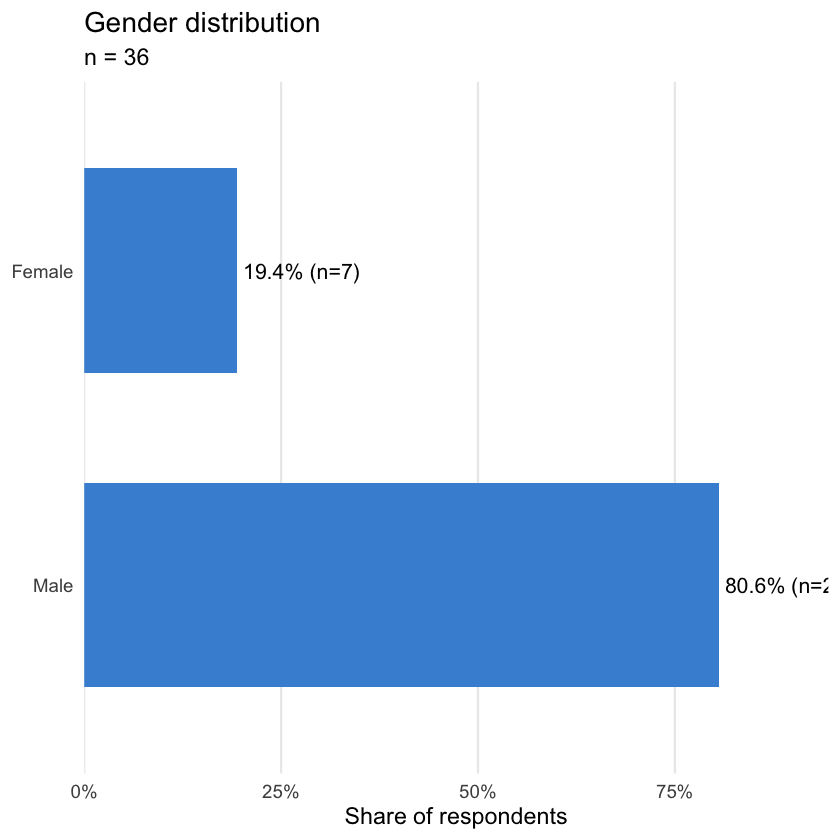

In [10]:
# ---  Gender Distribution Analysis (Horizontal Bar Chart) ---

# Calculate counts and percentages
# Note: After removing Age=10, 'Other' category count drops to 0
gender_stats <- df_good %>%
  summarise(
    Male_Count = sum(`Q3: _ Gender Selection\nOption 2: Male` == "M", na.rm = TRUE),
    Female_Count = sum(`Q3: _ Gender Selection\nOption 3: Female` == "F", na.rm = TRUE),
    Other_Count = sum(`Q3: _ Gender Selection\nOption 4: Other` == "X", na.rm = TRUE),
    Total = n()
  ) %>%
  pivot_longer(
    cols = c(Male_Count, Female_Count, Other_Count),
    names_to = "Gender",
    values_to = "Count"
  ) %>%
  mutate(
    Percentage = (Count / Total) * 100,
    Gender = gsub("_Count", "", Gender) # Clean up label names
  ) %>%
  filter(Count > 0) # Remove empty categories (like 'Other') for a cleaner plot

# Print Gender Table
print(gender_stats)

# Plot Horizontal Gender Distribution
gender_plot <- gender_stats %>%
  arrange(desc(Percentage)) %>%
  mutate(Gender = factor(Gender, levels = Gender))

ggplot(gender_plot, aes(x = Percentage, y = Gender)) +
  geom_col(width = 0.65, fill = "#4692d7") +
  geom_text(
    aes(label = sprintf("%.1f%% (n=%d)", Percentage, Count)),
    hjust = -0.05,
    size = 4.5
  ) +
  scale_x_continuous(
    labels = function(x) sprintf("%.0f%%", x),
    limits = c(0, max(gender_plot$Percentage) * 1.15),
    expand = expansion(mult = c(0, 0.02))
  ) +
  labs(
    title = "Gender distribution",
    subtitle = sprintf("n = %d", unique(gender_plot$Count) |> sum()),
    x = "Share of respondents",
    y = NULL
  ) +
  theme_minimal(base_size = 14) +
  theme(
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank()
  )

#### Age distribution

# A tibble: 3 × 3
  AgeGroup     n Percentage
  <fct>    <int>      <dbl>
1 18-24       13      36.1 
2 25-29       22      61.1 
3 30+          1       2.78


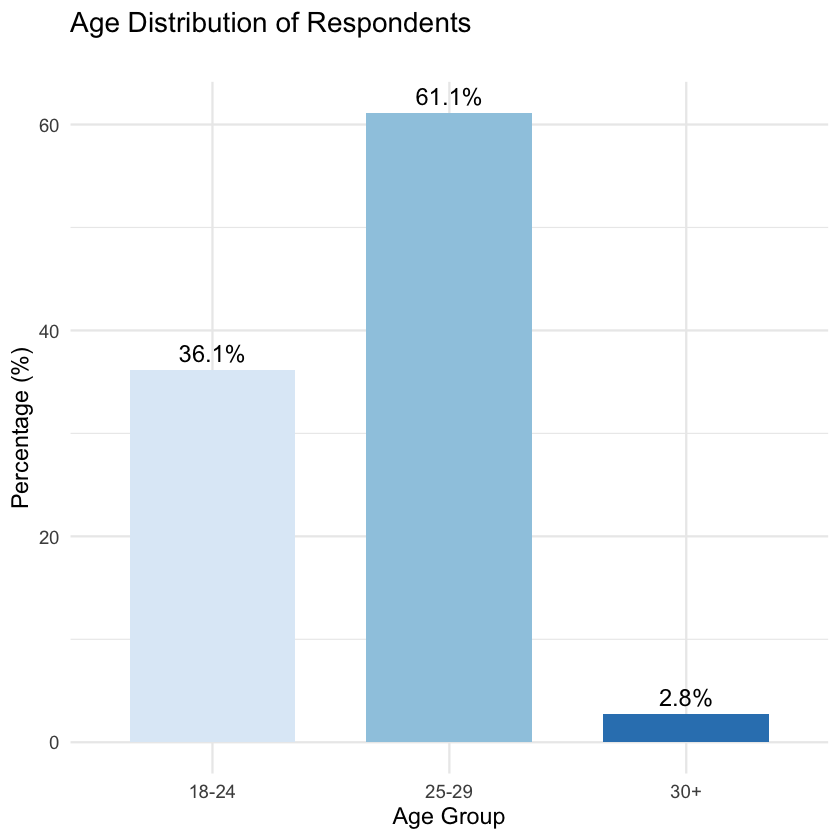

In [11]:
# ---  Age Distribution Analysis (Updated) ---

# Define Age Groups (Standardized for this young demographic)
# Groups: 18-24, 25-29, 30+
age_breaks <- c(18, 25, 30, 100)
age_labels <- c("18-24", "25-29", "30+")

# Create a new column for Age Group
df_good$AgeGroup <- cut(df_good[[age_col_name]],
  breaks = age_breaks,
  labels = age_labels,
  right = FALSE
)

# Calculate Counts and Percentages per Group
age_summary <- df_good %>%
  filter(!is.na(AgeGroup)) %>% # Remove any NAs if they exist
  count(AgeGroup) %>%
  mutate(
    Percentage = n / sum(n) * 100
  )

# Print the summary table
print(age_summary)

# Plot Age Group Distribution with Percentages
ggplot(age_summary, aes(x = AgeGroup, y = Percentage, fill = AgeGroup)) +
  geom_bar(stat = "identity", width = 0.7) +
  geom_text(aes(label = sprintf("%.1f%%", Percentage)), vjust = -0.5, size = 5) +
  scale_fill_brewer(palette = "Blues") +
  labs(
    title = "Age Distribution of Respondents",
    subtitle = "",
    x = "Age Group",
    y = "Percentage (%)"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")



#### Respondents location intensity



Attaching package: ‘maps’


The following object is masked from ‘package:purrr’:

    map




# A tibble: 6 × 3
  Latitude Longitude Respondent_Count
     <dbl>     <dbl>            <int>
1     45.5      9.19                8
2     45.5      9.19                6
3     51.2     71.4                 4
4     41.0     29.0                 2
5     43.3     76.9                 2
6     39.9     32.9                 1


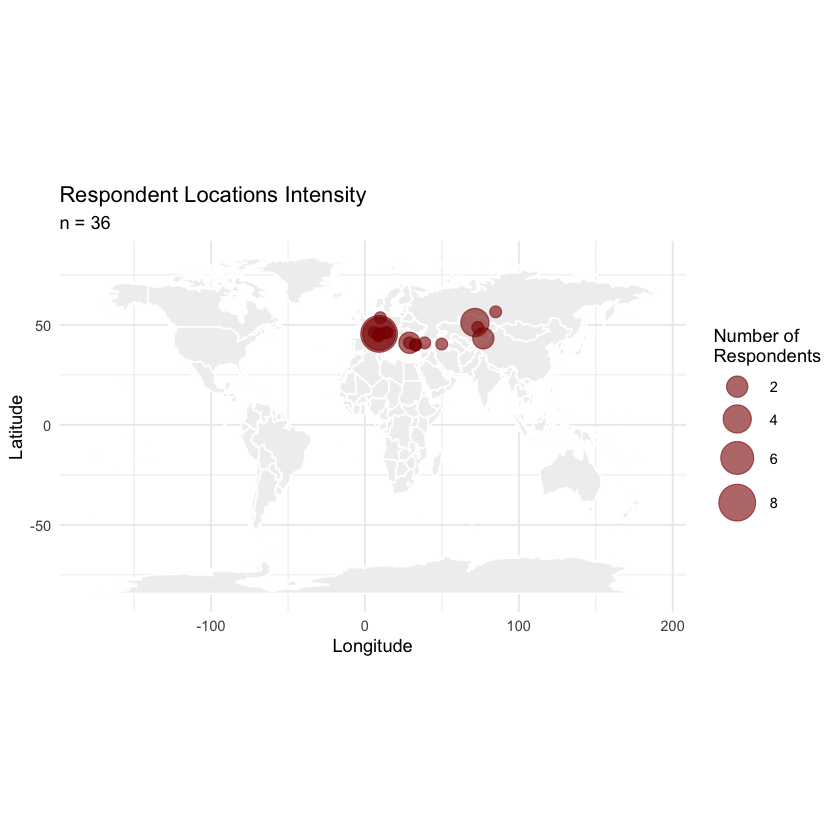

In [12]:
# --- Respondent Locations Map (Bubble Map) ---

# Load the maps library
library(maps)

# 1. Prepare Map Data
world_map <- map_data("world")

# 2. Prepare Respondent Data
# Ensure coordinates are numeric
lat_col <- "Location: Latitude"
lon_col <- "Location: Longitude"

df_good[[lat_col]] <- as.numeric(df_good[[lat_col]])
df_good[[lon_col]] <- as.numeric(df_good[[lon_col]])

# 3. Aggregate Data by Location
# This counts how many respondents are at each unique lat/lon coordinate
location_data <- df_good %>%
  group_by(Latitude = .data[[lat_col]], Longitude = .data[[lon_col]]) %>%
  summarise(Respondent_Count = n(), .groups = "drop")

# Print the top locations to check
print(head(location_data %>% arrange(desc(Respondent_Count))))

# 4. Create the Bubble Map
ggplot() +
  # Base World Map
  geom_polygon(
    data = world_map, aes(x = long, y = lat, group = group),
    fill = "#f0f0f0", color = "white"
  ) + # Light gray background
  # Add Bubbles
  geom_point(
    data = location_data,
    aes(x = Longitude, y = Latitude, size = Respondent_Count),
    color = "darkred", alpha = 0.6
  ) + # Semi-transparent red bubbles
  # Scale the bubbles
  scale_size_continuous(range = c(3, 10), name = "Number of\nRespondents") +
  # Fix aspect ratio and clean up theme
  coord_fixed(1.3) +
  labs(
    title = "Respondent Locations Intensity",
    subtitle = paste("n =", sum(location_data$Respondent_Count)),
    x = "Longitude", y = "Latitude"
  ) +
  theme_minimal() +
  theme(legend.position = "right") # Show legend to interpret bubble size



### 3.2 Behavioural characteristics of Respondents
#### Primary Sport / Activity Type


# A tibble: 4 × 4
  `Q5: _ Primary Sport/Activity Type`               n Percentage Category       
  <chr>                                         <int>      <dbl> <fct>          
1 Endurance / Outdoor (Cycling, Hiking, Skiing)     1       2.78 Endurance / Ou…
2 High Intensity (Running, Crossfit, Football)     13      36.1  High Intensity…
3 Indoor Fitness (Gym, Yoga, Pilates)              19      52.8  Indoor Fitness…
4 Other                                             3       8.33 Other          


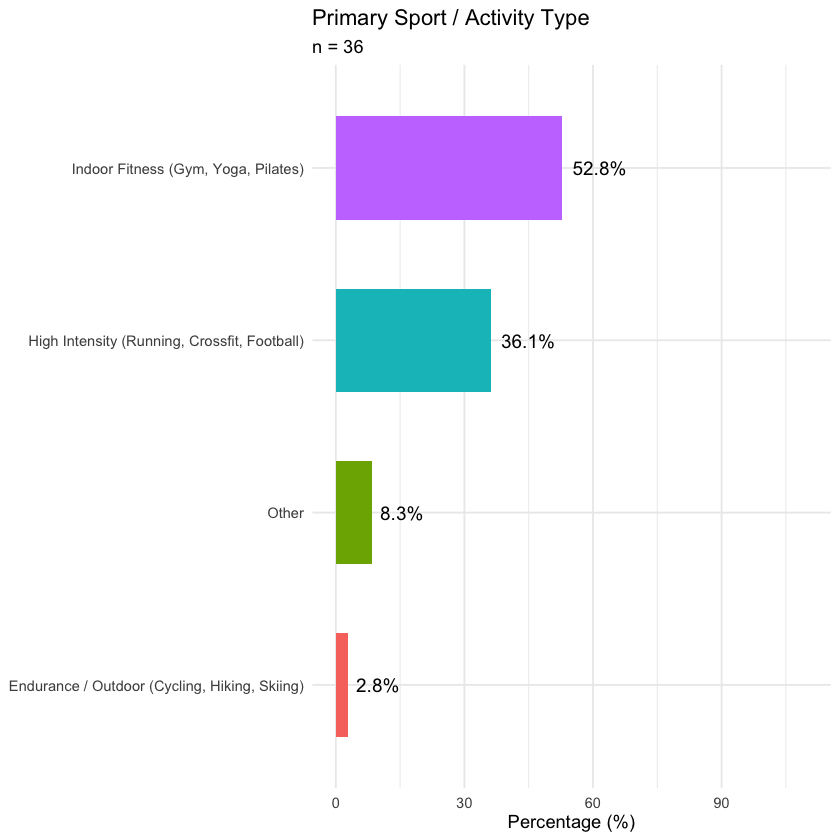

In [16]:

# Calculate counts and percentages
sport_stats <- df_good %>%
  filter(!is.na(!!sym(sport_col))) %>%
  count(!!sym(sport_col)) %>%
  mutate(
    Percentage = n / sum(n) * 100,
    Category = reorder(!!sym(sport_col), Percentage)
  )

# Print table
print(sport_stats)

# Plot Horizontal Bar Chart
ggplot(sport_stats, aes(x = Category, y = Percentage, fill = Category)) +
  geom_bar(stat = "identity", width = 0.6) +
  geom_text(aes(label = sprintf("%.1f%%", Percentage)), hjust = -0.2, size = 4) +
  scale_y_continuous(limits = c(0, 110)) + # Extra space for long labels
  coord_flip() +
  labs(
    title = "Primary Sport / Activity Type",
    subtitle = paste("n =", sum(sport_stats$n)),
    x = NULL,
    y = "Percentage (%)"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

#### Sports Participation Frequency

# A tibble: 3 × 4
  `Q4: _ Sports Participation Frequency`     n Percentage Category             
  <chr>                                  <int>      <dbl> <fct>                
1 1-2 times a week                          16       44.4 1-2 times a week     
2 3-4 times a week                          14       38.9 3-4 times a week     
3 Less than once a week                      6       16.7 Less than once a week


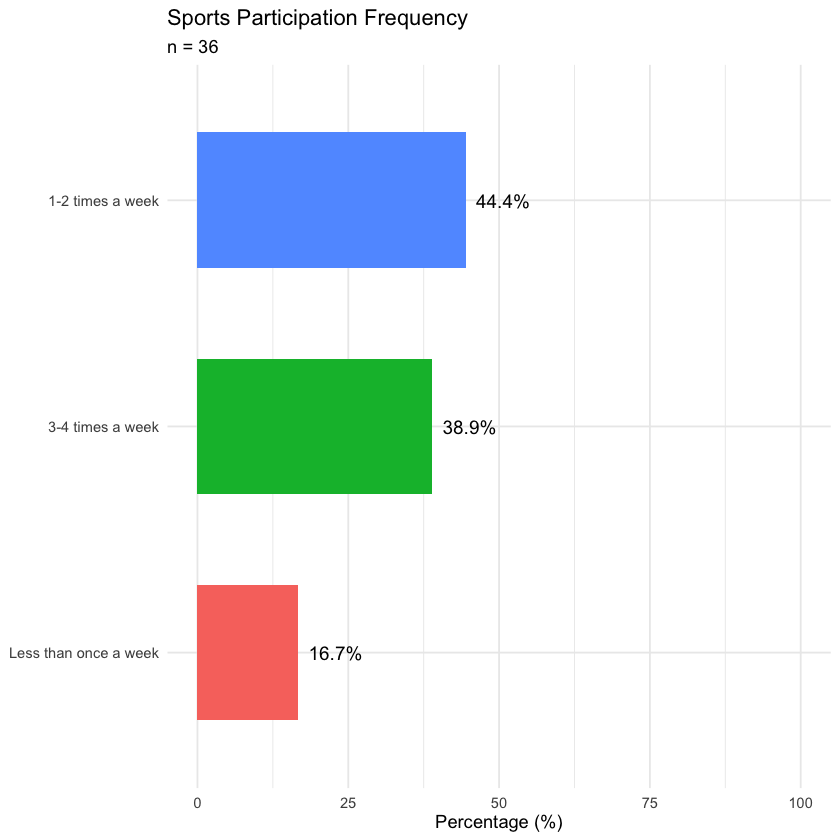

In [15]:

# Define the exact column names from the Excel file
freq_col <- "Q4: _ Sports Participation Frequency"
sport_col <- "Q5: _ Primary Sport/Activity Type"

# Calculate counts and percentages
freq_stats <- df_good %>% # Remove NAs
  count(!!sym(freq_col)) %>%
  mutate(
    Percentage = n / sum(n) * 100,
    # Reorder factors manually if needed (e.g., Daily > 3-4 times > 1-2 times)
    # Here we just use the raw text, but you can set levels to fix order
    Category = reorder(!!sym(freq_col), Percentage)
  )

# Print table
print(freq_stats)

# Plot Horizontal Bar Chart
ggplot(freq_stats, aes(x = Category, y = Percentage, fill = Category)) +
  geom_bar(stat = "identity", width = 0.6) +
  geom_text(aes(label = sprintf("%.1f%%", Percentage)), hjust = -0.2, size = 4) +
  scale_y_continuous(limits = c(0, 100)) +
  coord_flip() +
  labs(
    title = "Sports Participation Frequency",
    subtitle = paste("n =", sum(freq_stats$n)),
    x = NULL,
    y = "Percentage (%)"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

### 3.3. Consumer Preferences
#### Sportswear Design Preference Analysis

[1] "Design Preference Distribution:"
# A tibble: 3 × 4
  `Q7: _ Sportswear Design Preference`     n Percentage Design_Style         
  <chr>                                <int>      <dbl> <fct>                
1 Bold and visible                         1       2.78 Bold and visible     
2 Minimalistic design                     28      77.8  Minimalistic design  
3 Small design elements                    7      19.4  Small design elements


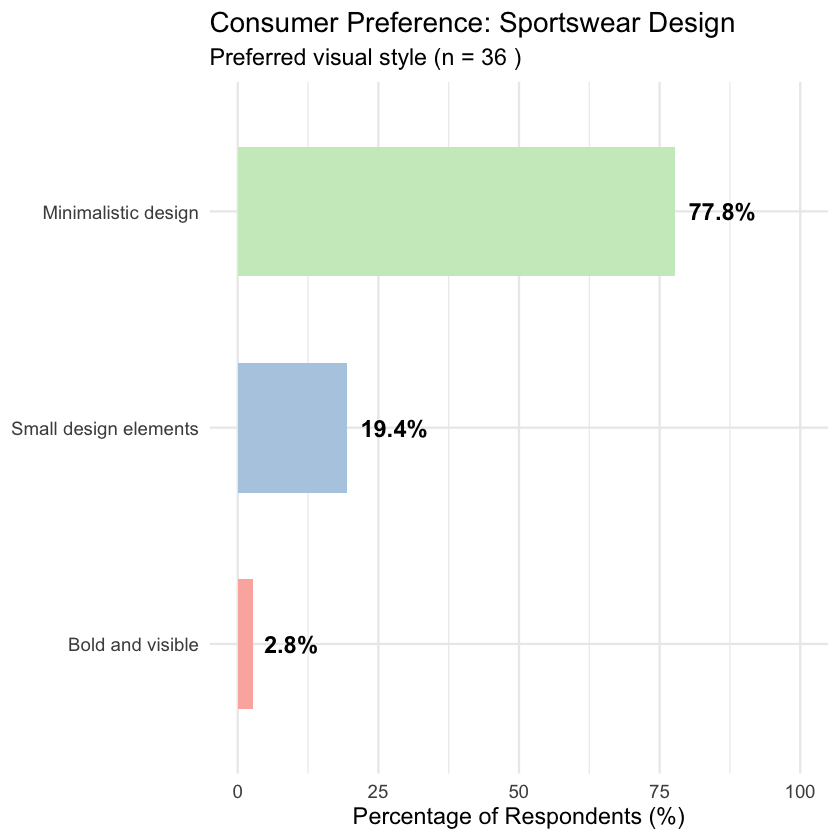

In [17]:
# Define the specific column for Design Preference
# (Using backticks because the name contains spaces and colons)
design_col <- "Q7: _ Sportswear Design Preference"

# 1. Calculate Counts and Percentages
design_stats <- df_good %>%
  filter(!is.na(!!sym(design_col))) %>% # Remove any missing answers
  count(!!sym(design_col)) %>%
  mutate(
    Percentage = n / sum(n) * 100,
    # Reorder categories by popularity (Most popular at top)
    Design_Style = reorder(!!sym(design_col), Percentage)
  )

# Print the table to see exact numbers
print("Design Preference Distribution:")
print(design_stats)

# 2. Create the Horizontal Bar Chart
ggplot(design_stats, aes(x = Design_Style, y = Percentage, fill = Design_Style)) +
  geom_bar(stat = "identity", width = 0.6) +

  # Add percentage labels
  geom_text(aes(label = sprintf("%.1f%%", Percentage)),
    hjust = -0.2, size = 5, fontface = "bold"
  ) +

  # Styling
  scale_fill_brewer(palette = "Pastel1") + # Soft colors
  scale_y_continuous(limits = c(0, 100)) + # Ensure space for labels
  coord_flip() + # Horizontal bars

  # Labels
  labs(
    title = "Consumer Preference: Sportswear Design",
    subtitle = paste("Preferred visual style (n =", sum(design_stats$n), ")"),
    x = NULL, # No label needed for categories
    y = "Percentage of Respondents (%)"
  ) +

  # Clean Theme
  theme_minimal(base_size = 14) +
  theme(legend.position = "none") # Hide legend as bars are labeled


#### Durability vs Performance Analysis

[1] "Durability vs Performance Preference:"
# A tibble: 2 × 3
  Priority_Label                       n Percentage
  <fct>                            <int>      <dbl>
1 "Durability\n(Long-lasting)"        29       80.6
2 "Performance\n(High-tech/Light)"     7       19.4


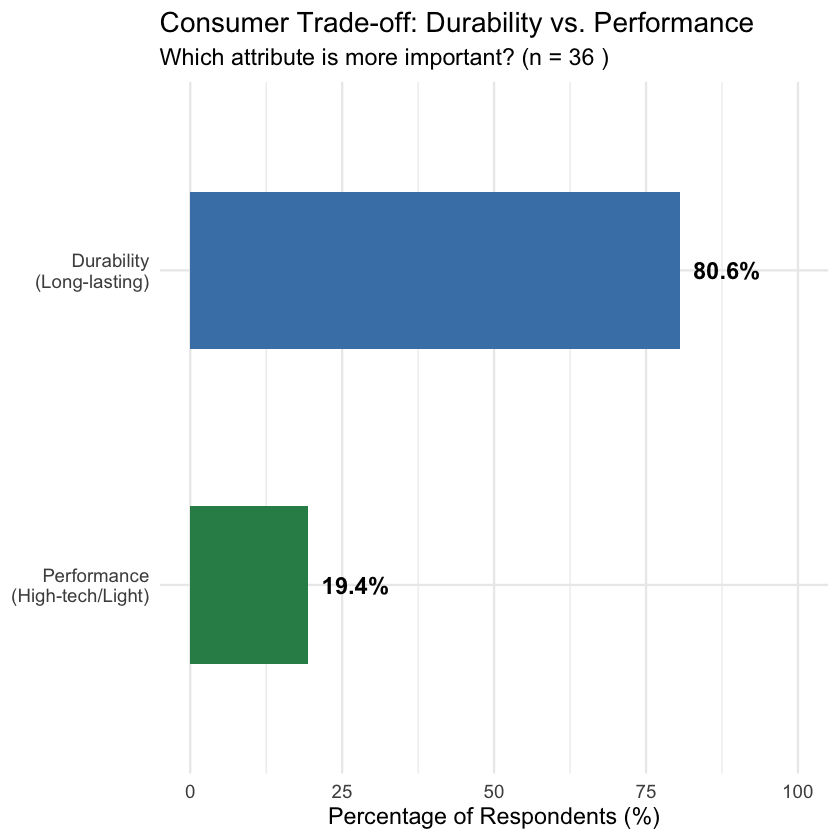

In [18]:
# Define the specific column for this question
# (Using backticks because of special characters in the name)
durability_col <- "Q6: _ Product Attribute Priority: Durability vs Performance"

# 1. Prepare Data
durability_stats <- df_good %>%
  filter(!is.na(!!sym(durability_col))) %>% # Remove missing answers
  mutate(
    # Simplify the long text labels for better plotting
    # We use 'case_when' to rename the full sentences to short keywords
    Priority_Label = case_when(
      grepl("Durability", !!sym(durability_col)) ~ "Durability\n(Long-lasting)",
      grepl("Performance", !!sym(durability_col)) ~ "Performance\n(High-tech/Light)",
      TRUE ~ "Other"
    )
  ) %>%
  count(Priority_Label) %>%
  mutate(
    Percentage = n / sum(n) * 100,
    # Reorder so the most popular one is at the top
    Priority_Label = reorder(Priority_Label, Percentage)
  )

# Print the table
print("Durability vs Performance Preference:")
print(durability_stats)

# 2. Create the Horizontal Bar Chart
ggplot(durability_stats, aes(x = Priority_Label, y = Percentage, fill = Priority_Label)) +
  geom_bar(stat = "identity", width = 0.5) +

  # Add percentage labels
  geom_text(aes(label = sprintf("%.1f%%", Percentage)),
    hjust = -0.2, size = 5, fontface = "bold"
  ) +

  # Styling
  scale_fill_manual(values = c("#2E8B57", "#4682B4")) + # Green for Durability, Blue for Performance
  scale_y_continuous(limits = c(0, 100)) +
  coord_flip() +

  # Labels
  labs(
    title = "Consumer Trade-off: Durability vs. Performance",
    subtitle = paste("Which attribute is more important? (n =", sum(durability_stats$n), ")"),
    x = NULL,
    y = "Percentage of Respondents (%)"
  ) +

  # Clean Theme
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

### 3.4. Attribute importance

In [19]:
# ---  Hierarchical Conjoint Analysis (Corrected Calculation) ---

# Load necessary libraries


library(glmnet)
library(dplyr)
library(tidyr)
library(ggplot2)
library(readxl)
design_raw <- read_excel(file_path, sheet = "Experimental design", skip = 2)
responses_raw <- read_excel(file_path, sheet = "Raw responses", skip = 2)

responses_long <- responses_raw %>%
  semi_join(df_good, by = "participant_id") %>%
  select(participant_id, starts_with("q")) %>%
  pivot_longer(cols = starts_with("q"), names_to = "QES_str", values_to = "Selected_ALT") %>%
  mutate(QES = parse_number(QES_str)) %>%
  select(-QES_str)

conjoint_data <- design_raw %>%
  semi_join(df_good, by = "participant_id") %>%
  inner_join(responses_long, by = c("participant_id", "QES")) %>%
  mutate(Choice = ifelse(ALT == Selected_ALT, 1, 0)) %>%
  mutate(across(starts_with("A"), as.factor))

In [20]:
 
# -------------------------------------------------------
individual_utilities <- data.frame()
participants <- unique(conjoint_data$participant_id)

print(paste("Running individual models for", length(participants), "respondents..."))

for (pid in participants) {
  person_data <- conjoint_data %>% filter(participant_id == pid)

  # Model Matrix (Remove Intercept)
  x_matrix <- model.matrix(Choice ~ A1 + A2 + A3 + A4 + A5 - 1, data = person_data)
  y_vector <- person_data$Choice
  

  tryCatch(
    {
      fit <- glmnet(x_matrix, y_vector, family = "binomial", alpha = 0, lambda = 0.1)
      coefs <- as.matrix(coef(fit))
      
      # Explicitly create the dataframe and ensure column naming
      person_coefs <- data.frame(
        participant_id = pid,
        Level_Code = rownames(coefs),
        Utility = as.numeric(coefs[, 1]),
        stringsAsFactors = FALSE  # Ensures Level_Code is text, not a factor
      ) %>%
        filter(Level_Code != "(Intercept)") %>%
        # Perform the substr transformation INSIDE the safe block
        mutate(Attribute_ID = substr(Level_Code, 1, 2))
      
        individual_utilities <- bind_rows(individual_utilities, person_coefs)
    },
    error = function(e) {
      message(paste("Error with participant", pid, ":", e$message))
      return(NULL)
    }
  )
}


[1] "Running individual models for 28 respondents..."


Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Error with participant 256052440 : error in evaluating the argument 'x' in selecting a method for function 'drop': non-conformable arguments

Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Error with participant 256099696 : one multinomial or binomial class has 1 or 0 observations; not allowed

Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“

These warnings are given only because That participants 256052440 and 256099696 chose the same option every time. The other warnings ae becasue of few observations which are not ideal for the conjoint.

In [21]:
# -------------------------------------------------------
#NEW: Calculate Importance PER PERSON First
# -------------------------------------------------------

# 1. Clean up the data

indiv_clean <- individual_utilities %>%
  mutate(
    Attribute_ID = substr(Level_Code, 1, 2)
  )

# 2. Add Reference Levels (Utility = 0) for every person
# This ensures the range calculation is correct (max - min including 0)
ref_levels <- unique(indiv_clean[, c("participant_id", "Attribute_ID")]) %>%
  mutate(Level_Code = paste0(Attribute_ID, "L1"), Utility = 0)

indiv_full <- bind_rows(indiv_clean, ref_levels)

# 3. Calculate Range (Importance) for EACH Person for EACH Attribute
person_importance <- indiv_full %>%
  group_by(participant_id, Attribute_ID) %>%
  summarise(
    Range = max(Utility) - min(Utility),
    .groups = "drop"
  )

# 4. Average the Ranges (The "Conjointly" Method)
avg_importance <- person_importance %>%
  group_by(Attribute_ID) %>%
  summarise(
    Avg_Range = mean(Range)
  ) %>%
  mutate(
    Importance_Pct = Avg_Range / sum(Avg_Range) * 100,
    # Add Labels
    Attribute_Label = case_when(
      Attribute_ID == "A1" ~ "Price",
      Attribute_ID == "A2" ~ "Colour",
      Attribute_ID == "A3" ~ "Main Material",
      Attribute_ID == "A4" ~ "Made in Italy",
      Attribute_ID == "A5" ~ "Availability",
      TRUE ~ Attribute_ID
    )
  ) %>%
  arrange(desc(Importance_Pct))

print("Revised Attribute Importance (Average of Ranges):")
print(avg_importance)


[1] "Revised Attribute Importance (Average of Ranges):"
# A tibble: 5 × 4
  Attribute_ID Avg_Range Importance_Pct Attribute_Label
  <chr>            <dbl>          <dbl> <chr>          
1 A1               2.16           37.7  Price          
2 A3               1.76           30.9  Main Material  
3 A2               0.895          15.7  Colour         
4 A4               0.500           8.74 Made in Italy  
5 A5               0.400           7.00 Availability   


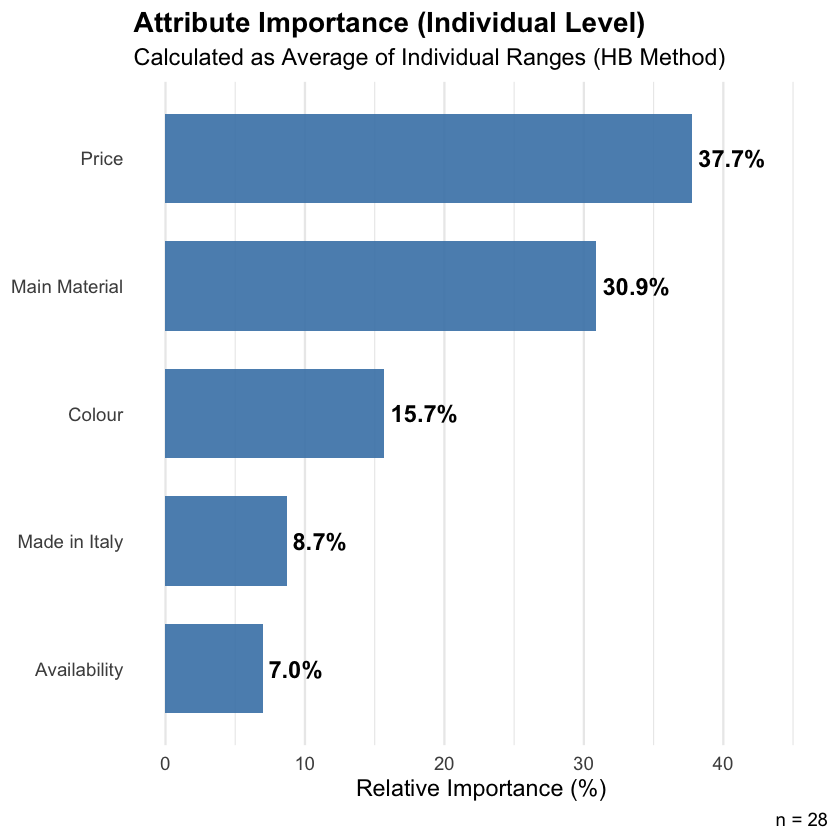

In [22]:
# -------------------------------------------------------
#  Plot the Result
# -------------------------------------------------------
ggplot(avg_importance, aes(x = reorder(Attribute_Label, Importance_Pct), y = Importance_Pct)) +
  geom_col(fill = "steelblue", alpha = 0.9, width = 0.7) +
  geom_text(aes(label = sprintf("%.1f%%", Importance_Pct)),
    hjust = -0.1, size = 5, fontface = "bold"
  ) +
  coord_flip() +
  scale_y_continuous(limits = c(0, max(avg_importance$Importance_Pct) * 1.2)) +
  labs(
    title = "Attribute Importance (Individual Level)",
    subtitle = "Calculated as Average of Individual Ranges (HB Method)",
    x = NULL,
    y = "Relative Importance (%)",
    caption = paste("n =", length(participants))
  ) +
  theme_minimal(base_size = 14) +
  theme(
    panel.grid.major.y = element_blank(),
    plot.title = element_text(face = "bold")
  )

### 3.5 Preferences for Levels


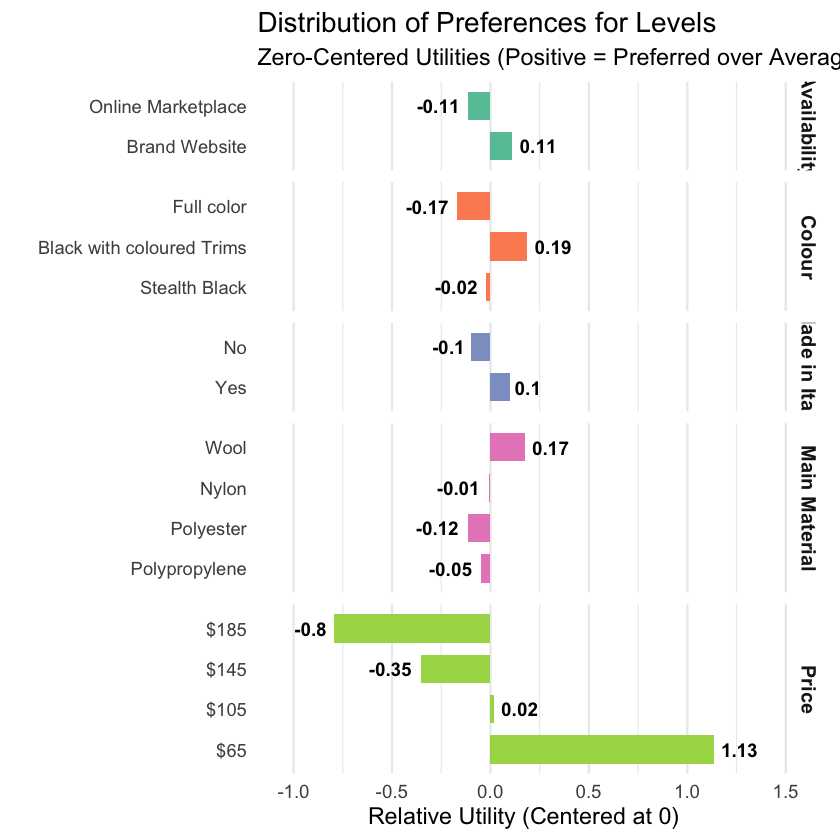

In [23]:
# Load stringr for text cleaning
if (!require(stringr)) install.packages("stringr")
library(stringr)

# 1. Check if individual_utilities exists
if (!exists("individual_utilities") || nrow(individual_utilities) == 0) {
  stop("Error: 'individual_utilities' is empty. Please check Section 9.2.")
}

# 2. Clean the Level Codes from the Model Output
# This fixes the issue where model.matrix outputs names like "A1A1L2" instead of "A1L2"
individual_utilities_clean <- individual_utilities %>%
  mutate(
    # Extract exactly the "A#L#" pattern from the messy row names
    Level_Code_Clean = str_extract(Level_Code, "A[0-9]+L[0-9]+")
  ) %>%
  # Filter out rows where no code was found (like Intercepts)
  filter(!is.na(Level_Code_Clean))

# 3. Define the Map (Your specific labels)
level_map <- data.frame(
  Level_Code = c(
    "A1L1", "A1L2", "A1L3", "A1L4",
    "A2L1", "A2L2", "A2L3",
    "A3L1", "A3L2", "A3L3", "A3L4",
    "A4L1", "A4L2",
    "A5L1", "A5L2"
  ),
  Level_Name = c(
    "$65", "$105", "$145", "$185",
    "Stealth Black", "Black with coloured Trims", "Full color",
    "Polypropylene", "Polyester", "Nylon", "Wool",
    "Yes", "No",
    "Brand Website", "Online Marketplace"
  ),
  Attribute_Name = c(
    rep("Price", 4), rep("Colour", 3), rep("Main Material", 4),
    rep("Made in Italy", 2), rep("Availability", 2)
  )
)

# 4. Prepare Plot Data (Full Grid Method)
# We create a grid of All Participants x All Levels to handle reference levels (which are 0)
full_grid <- expand.grid(
  participant_id = unique(individual_utilities_clean$participant_id),
  Level_Code = level_map$Level_Code,
  stringsAsFactors = FALSE
)

plot_data <- full_grid %>%
  # Join with the CLEANED utilities
  left_join(individual_utilities_clean, by = c("participant_id", "Level_Code" = "Level_Code_Clean")) %>%
  # Fill Reference Levels (NAs) with 0
  mutate(Utility = ifelse(is.na(Utility), 0, Utility)) %>%
  # Join with readable names
  left_join(level_map, by = "Level_Code")

# 5. Calculate Zero-Centered Scores (The "Conjointly" Style)
plot_data_centered <- plot_data %>%
  # A. Center utilities for EACH person (so their average utility is 0)
  group_by(participant_id, Attribute_Name) %>%
  mutate(Person_Centered_Utility = Utility - mean(Utility)) %>%
  ungroup() %>%
  # B. Calculate the Market Average
  group_by(Attribute_Name, Level_Name) %>%
  summarise(
    Avg_Utility = mean(Person_Centered_Utility),
    .groups = "drop"
  ) %>%
  # C. Order the levels logically (using the map order)
  mutate(Level_Name = factor(Level_Name, levels = level_map$Level_Name))

# 6. Generate the Plot
ggplot(plot_data_centered, aes(x = Avg_Utility, y = Level_Name, fill = Attribute_Name)) +
  geom_col(width = 0.7) +

  # Add value labels
  geom_text(aes(label = round(Avg_Utility, 2)),
    hjust = ifelse(plot_data_centered$Avg_Utility > 0, -0.2, 1.2),
    size = 4, fontface = "bold"
  ) +

  # Group by Attribute
  facet_grid(Attribute_Name ~ ., scales = "free_y", space = "free") +

  # Styling
  scale_fill_brewer(palette = "Set2") +
  labs(
    title = "Distribution of Preferences for Levels",
    subtitle = "Zero-Centered Utilities (Positive = Preferred over Average)",
    x = "Relative Utility (Centered at 0)",
    y = ""
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "none",
    panel.grid.major.y = element_blank(),
    strip.text = element_text(size = 12, face = "bold"),
    axis.text.y = element_text(size = 11)
  ) +
  # Ensure labels fit
  scale_x_continuous(expand = expansion(mult = 0.2))



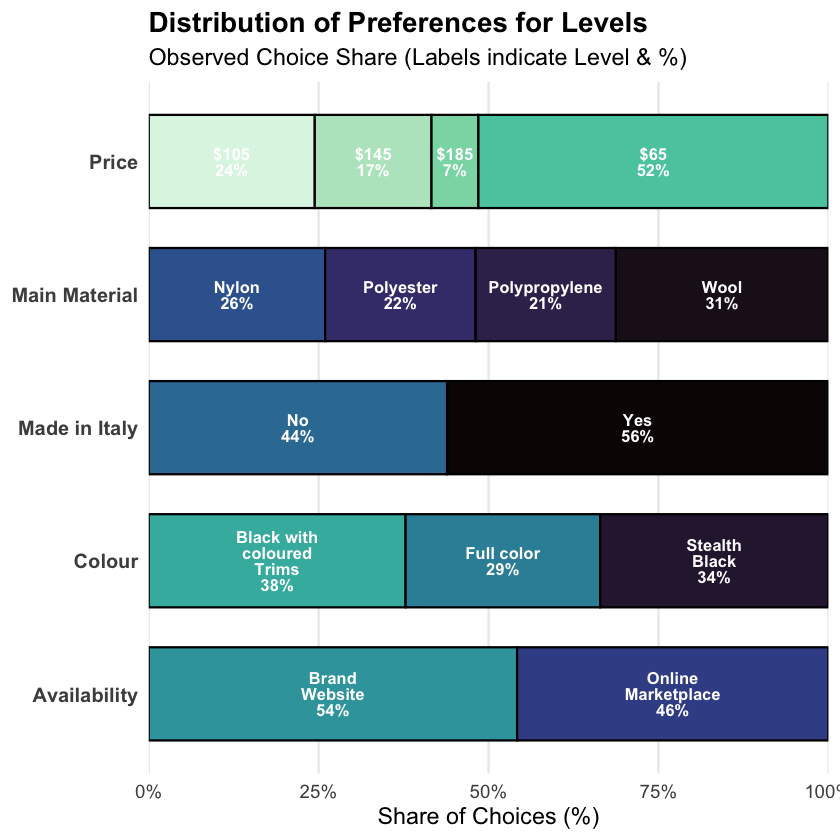

In [24]:
# ---  Distribution of Preferences (Observed Choice Frequency) ---
#  Darker Colors, No Legend, Labels inside Bars

# 1. Prepare Data (Same as before)
observed_choices <- design_raw %>%
  inner_join(responses_long, by = c("participant_id", "QES")) %>%
  filter(ALT == Selected_ALT)

counts_data <- observed_choices %>%
  select(A1, A2, A3, A4, A5) %>%
  pivot_longer(cols = everything(), names_to = "Attribute_ID", values_to = "Level_Code") %>%
  left_join(level_map, by = "Level_Code") %>%
  count(Attribute_Name, Level_Name) %>%
  group_by(Attribute_Name) %>%
  mutate(
    Percentage = n / sum(n) * 100
  ) %>%
  ungroup() %>%
  arrange(Attribute_Name, desc(Percentage))

# 2. Create the Plot
# We use 'str_wrap' to ensure long names don't spill out
library(stringr)

ggplot(counts_data, aes(y = Attribute_Name, x = Percentage, fill = Level_Name)) +

  # Stacked Bar
  geom_col(position = position_stack(reverse = TRUE), width = 0.7, color = "black") +

  # Labels INSIDE the bars (Name + %)
  # We only show labels if the segment is big enough (>5%) to be readable
  geom_text(
    aes(label = ifelse(Percentage > 5,
      paste0(str_wrap(Level_Name, 12), "\n", round(Percentage), "%"),
      ""
    )),
    position = position_stack(vjust = 0.5, reverse = TRUE),
    size = 3.5,
    color = "white",
    fontface = "bold",
    lineheight = 0.8
  ) +

  # Darker Color Palette ("Mako" is a dark, professional blue/teal/black range)
  scale_fill_viridis_d(option = "mako", direction = -1) +

  # Axis Formatting
  scale_x_continuous(labels = function(x) paste0(x, "%"), expand = c(0, 0)) +

  # Labels
  labs(
    title = "Distribution of Preferences for Levels",
    subtitle = "Observed Choice Share (Labels indicate Level & %)",
    x = "Share of Choices (%)",
    y = NULL
  ) +

  # Clean Theme
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "none", # Hides the legend completely
    panel.grid.major.y = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.text.y = element_text(face = "bold", size = 12),
    plot.title = element_text(face = "bold")
  )



### 3.6. Marginal Willingness to pay

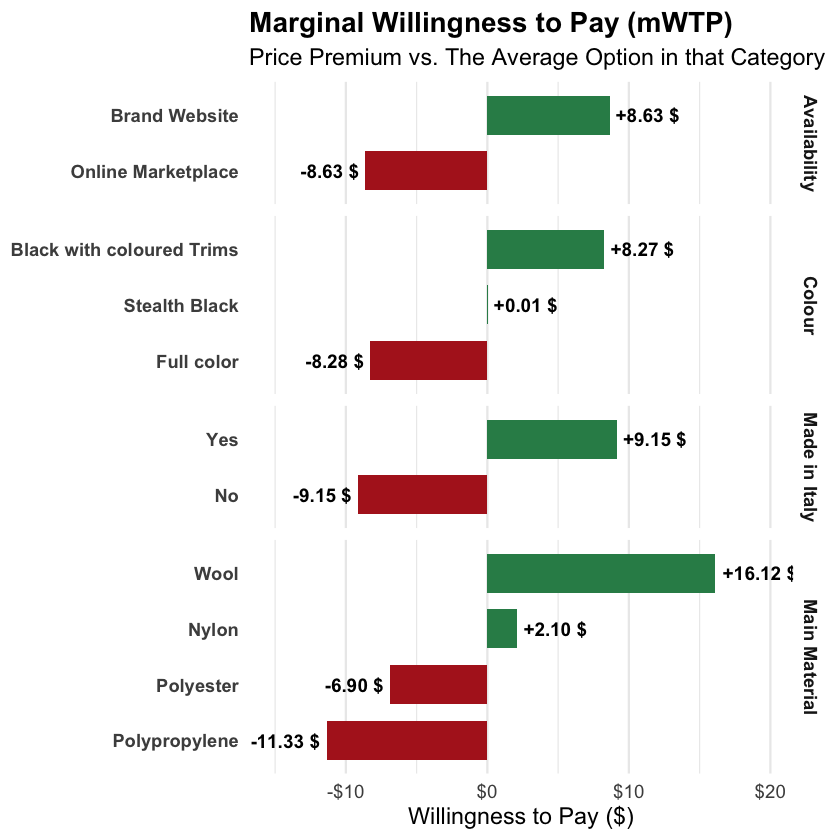

In [25]:
# --- Marginal Willingness to Pay (mWTP) ---
library(dplyr)
library(tidyr)
library(glmnet)
library(rlang)


# 1. Prepare Data with Numeric Price
# We need to run a specific model where Price is continuous (numeric)
# to get a single "Price Coefficient" (slope).

wtp_data <- design_raw %>%
  inner_join(responses_long, by = c("participant_id", "QES")) %>%
  mutate(Choice = ifelse(ALT == Selected_ALT, 1, 0)) %>%
  # Convert A1 (Price) to Numeric values
  mutate(
    Price_Numeric = case_when(
      A1 == "A1L1" ~ 65,
      A1 == "A1L2" ~ 105,
      A1 == "A1L3" ~ 145,
      A1 == "A1L4" ~ 185
    )
  ) %>%
  # Join with our map to get names for other attributes
  left_join(level_map, by = c("A2" = "Level_Code")) %>%
  rename(Colour = Level_Name) %>%
  left_join(level_map, by = c("A3" = "Level_Code")) %>%
  rename(Material = Level_Name) %>%
  left_join(level_map, by = c("A4" = "Level_Code")) %>%
  rename(Origin = Level_Name) %>%
  left_join(level_map, by = c("A5" = "Level_Code")) %>%
  rename(Availability = Level_Name)
# 2. Run Conditional Logit Model (Linear Price)
library(survival)

# We use "strata(QES)" to group choices by task
wtp_model <- clogit(Choice ~ Price_Numeric + Colour + Material + Origin + Availability + strata(QES),
  data = wtp_data
)

# 3. Extract Coefficients & Calculate WTP
coefs <- coef(wtp_model)
price_coef <- coefs["Price_Numeric"]

# Calculate WTP: (Utility / -Price_Coef)
# We multiply by -1 because Price has a negative utility (higher price = less likely to buy)
wtp_values <- data.frame(
  Term = names(coefs),
  Utility = coefs
) %>%
  filter(Term != "Price_Numeric") %>%
  mutate(
    # Clean the term names (remove variable prefix)
    Level_Name = str_remove(Term, "Colour|Material|Origin|Availability"),
    # Calculate Raw WTP ($)
    Raw_WTP = Utility / (-price_coef)
  )

# 4. Zero-Center WTP (Find value relative to Average)
# We need to bring back the reference levels (which have 0 utility/WTP)
# and then center everything so the average for an attribute is $0.

# A. Create a full list of non-price levels
non_price_map <- level_map %>% filter(Attribute_Name != "Price")

wtp_plot_data <- non_price_map %>%
  left_join(wtp_values, by = "Level_Name") %>%
  mutate(Raw_WTP = ifelse(is.na(Raw_WTP), 0, Raw_WTP)) %>% # Reference levels = $0
  group_by(Attribute_Name) %>%
  mutate(
    # Center: How much MORE would you pay for this vs the average option?
    Centered_WTP = Raw_WTP - mean(Raw_WTP)
  ) %>%
  ungroup() %>%
  arrange(Attribute_Name, desc(Centered_WTP))

# 5. Visualize WTP
ggplot(wtp_plot_data, aes(x = Centered_WTP, y = reorder(Level_Name, Centered_WTP), fill = Centered_WTP > 0)) +
  geom_col(width = 0.7) +

  # Add Dollar Labels
  geom_text(aes(label = sprintf("%+.2f $", Centered_WTP)),
    hjust = ifelse(wtp_plot_data$Centered_WTP > 0, -0.1, 1.1),
    size = 4, fontface = "bold"
  ) +

  # Facet by Attribute
  facet_grid(Attribute_Name ~ ., scales = "free_y", space = "free") +

  # Colors: Green for Positive, Red for Negative
  scale_fill_manual(values = c("TRUE" = "#2E8B57", "FALSE" = "#B22222")) +

  # Axis & Labels
  scale_x_continuous(labels = scales::dollar_format(), expand = expansion(mult = 0.2)) +
  labs(
    title = "Marginal Willingness to Pay (mWTP)",
    subtitle = "Price Premium vs. The Average Option in that Category",
    x = "Willingness to Pay ($)",
    y = NULL
  ) +

  # Theme
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "none",
    panel.grid.major.y = element_blank(),
    strip.text = element_text(size = 11, face = "bold"),
    axis.text.y = element_text(size = 11, face = "bold"),
    plot.title = element_text(face = "bold")
  )


### 3.7. Utility Heatmap


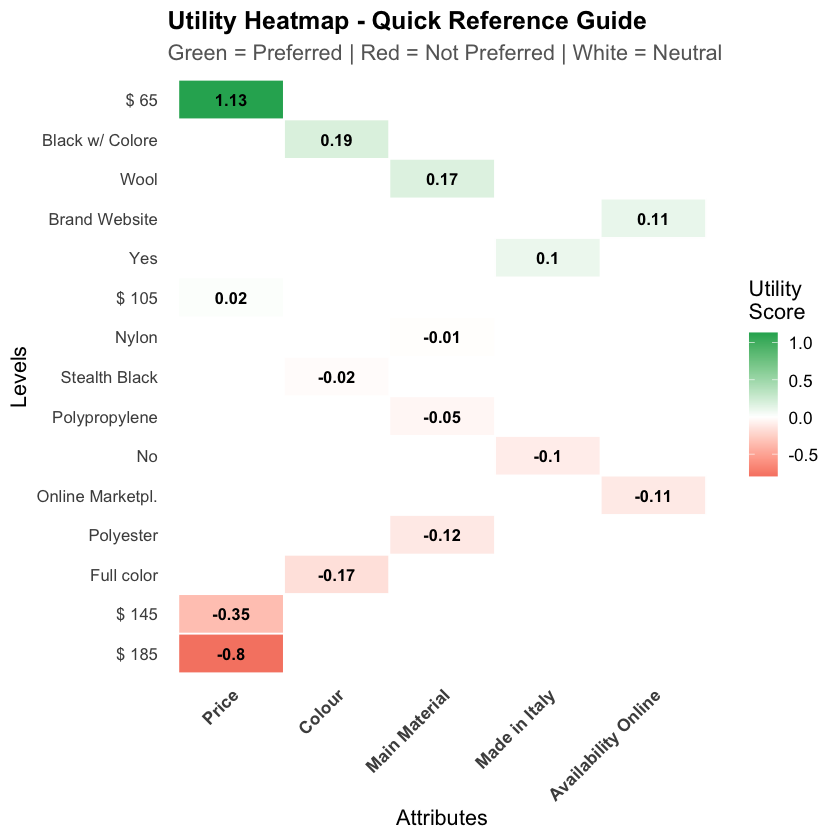

In [27]:
# 1. Prepare heatmap data from the zero-centered utilities (Section 9.5)
# We need each level to appear only in its own attribute column
heatmap_data <- plot_data_centered %>%
  mutate(
    # Shorten long level names to match the reference style
    Level_Short = case_when(
      Level_Name == "Black with coloured Trims" ~ "Black w/ Colore",
      Level_Name == "Stealth Black" ~ "Stealth Black",
      Level_Name == "Full color" ~ "Full color",
      Level_Name == "Brand Website" ~ "Brand Website",
      Level_Name == "Online Marketplace" ~ "Online Marketpl.",
      Level_Name == "$65" ~ "$ 65",
      Level_Name == "$105" ~ "$ 105",
      Level_Name == "$145" ~ "$ 145",
      Level_Name == "$185" ~ "$ 185",
      TRUE ~ as.character(Level_Name)
    ),
    # Rename attributes to match the reference image
    Attribute_Short = case_when(
      Attribute_Name == "Availability" ~ "Availability Online",
      TRUE ~ as.character(Attribute_Name)
    )
  )

# 2. Create a full grid of all levels x all attributes (most cells will be NA)
all_levels <- unique(heatmap_data$Level_Short)
all_attributes <- unique(heatmap_data$Attribute_Short)

full_heatmap <- expand.grid(
  Level_Short = all_levels,
  Attribute_Short = all_attributes,
  stringsAsFactors = FALSE
) %>%
  left_join(
    heatmap_data %>% select(Level_Short, Attribute_Short, Avg_Utility),
    by = c("Level_Short", "Attribute_Short")
  )

# 3. Order levels by utility (most preferred at top, least at bottom)
level_order <- heatmap_data %>%
  arrange(Avg_Utility) %>%
  pull(Level_Short)

full_heatmap$Level_Short <- factor(full_heatmap$Level_Short, levels = level_order)

# 4. Set attribute order to match the reference
attr_order <- c("Price", "Colour", "Main Material", "Made in Italy", "Availability Online")
full_heatmap$Attribute_Short <- factor(full_heatmap$Attribute_Short, levels = attr_order)

# 5. Create the Heatmap Plot
ggplot(full_heatmap, aes(x = Attribute_Short, y = Level_Short, fill = Avg_Utility)) +
  geom_tile(color = "white", linewidth = 0.5) +

  # Add utility score labels (only where a value exists)
  geom_text(
    aes(label = ifelse(!is.na(Avg_Utility), round(Avg_Utility, 2), "")),
    size = 3.5, fontface = "bold"
  ) +

  # Diverging color scale: Red (negative) -> White (zero) -> Green (positive)
  scale_fill_gradient2(
    low = "#E74C3C",
    mid = "white",
    high = "#27AE60",
    midpoint = 0,
    na.value = "white",
    name = "Utility\nScore"
  ) +

  # Labels
  labs(
    title = "Utility Heatmap - Quick Reference Guide",
    subtitle = "Green = Preferred | Red = Not Preferred | White = Neutral",
    x = "Attributes",
    y = "Levels"
  ) +

  # Theme
  theme_minimal(base_size = 13) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, face = "bold"),
    axis.text.y = element_text(size = 10),
    panel.grid = element_blank(),
    plot.title = element_text(face = "bold", size = 15),
    plot.subtitle = element_text(color = "gray40"),
    legend.position = "right"
  )



### 3.8. Product Strategy and Positioning

[1] "Market Simulation Results (Individual-Level Logit):"
            Scenario Strategy_Type Market_Share
1     Forcetek Ideal    Best Combo    32.327322
2   Forcetek Premium  Premium Play    28.248908
3     Forcetek Value  Value Leader    23.581871
4 Generic Competitor     Mid-Range    10.223784
5    Weak Competitor   Worst Combo     5.618116
                                                            Description
1                       $65 | Full color | Wool | Italy | Brand Website
2       $105 | Black with coloured Trims | Wool | Italy | Brand Website
3      $65 | Stealth Black | Polyester | Not Italy | Online Marketplace
4     $145 | Stealth Black | Polyester | Not Italy | Online Marketplace
5 $185 | Stealth Black | Polypropylene | Not Italy | Online Marketplace


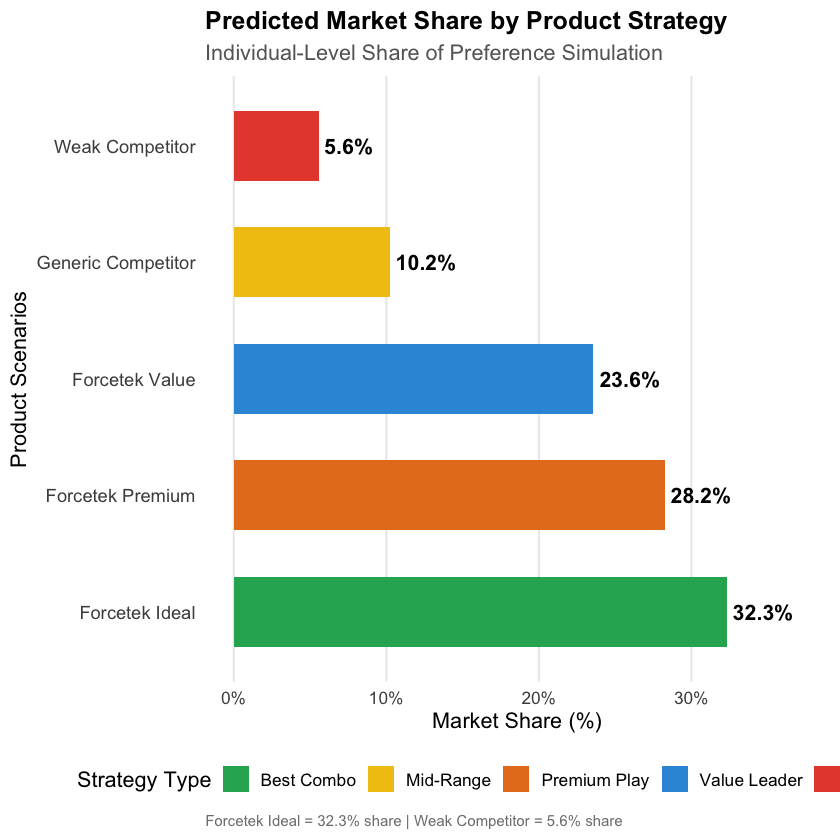

In [30]:
# METHODOLOGY: Individual-Level Share of Preference
# For each respondent:
#   1. Sum their personal part-worth utilities for each scenario
#   2. Apply logit: P(choose_i) = exp(V_i) / sum(exp(V_j))
# Then average the probabilities across ALL respondents.
# This produces properly differentiated shares (unlike aggregate-level simulation).

# 1. Build individual-level utility lookup (from Section 9.3)
# indiv_full has raw Level_Codes like "A2A2L3" from model.matrix — clean to "A2L3"
indiv_lookup <- indiv_full %>%
  mutate(
    Level_Code = ifelse(
      grepl("^A[0-9]+L[0-9]+$", Level_Code),
      Level_Code,
      str_extract(Level_Code, "A[0-9]+L[0-9]+")
    )
  ) %>%
  filter(!is.na(Level_Code)) %>%
  left_join(level_map, by = "Level_Code") %>%
  select(participant_id, Level_Code, Level_Name, Attribute_Name, Utility)

# 2. Define Product Scenarios using Level_Codes
# Each row = one scenario, columns = attribute level codes
scenario_profiles <- data.frame(
  Scenario = c(
    "Forcetek Ideal",
    "Forcetek Premium",
    "Forcetek Value",
    "Generic Competitor",
    "Weak Competitor"
  ),
  Strategy_Type = c(
    "Best Combo",
    "Premium Play",
    "Value Leader",
    "Mid-Range",
    "Worst Combo"
  ),
  # A1=Price, A2=Colour, A3=Material, A4=Origin, A5=Availability
  A1 = c("A1L1", "A1L2", "A1L1", "A1L3", "A1L4"),
  A2 = c("A2L3", "A2L2", "A2L1", "A2L1", "A2L1"),
  A3 = c("A3L4", "A3L4", "A3L2", "A3L2", "A3L1"),
  A4 = c("A4L1", "A4L1", "A4L2", "A4L2", "A4L2"),
  A5 = c("A5L1", "A5L1", "A5L2", "A5L2", "A5L2"),
  stringsAsFactors = FALSE
)
# Scenario descriptions:
# Forcetek Ideal:    $65  + Full color     + Wool     + Italy Yes + Brand Website
# Forcetek Premium:  $105 + Black w/ Trims + Wool     + Italy Yes + Brand Website
# Forcetek Value:    $65  + Stealth Black  + Polyester + Italy No + Online Marketplace
# Generic Competitor:$145 + Stealth Black  + Polyester + Italy No + Online Marketplace
# Weak Competitor:   $185 + Stealth Black  + Polyprop. + Italy No + Online Marketplace

# 3. For each respondent, compute total utility for each scenario
all_participants <- unique(indiv_lookup$participant_id)

# Create a wide utility table: one row per participant, one column per level code
# Aggregate duplicates (same person + same level) by taking the mean
indiv_wide <- indiv_lookup %>%
  select(participant_id, Level_Code, Utility) %>%
  group_by(participant_id, Level_Code) %>%
  summarise(Utility = mean(Utility, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from = Level_Code, values_from = Utility, values_fill = 0)

# Calculate total utility per scenario per participant
for (s in 1:nrow(scenario_profiles)) {
  col_name <- scenario_profiles$Scenario[s]
  codes <- as.character(scenario_profiles[s, c("A1", "A2", "A3", "A4", "A5")])
  # Sum utilities for this scenario's attribute levels
  indiv_wide[[col_name]] <- rowSums(indiv_wide[, codes, drop = FALSE], na.rm = TRUE)
}

# 4. Apply Logit at Individual Level
scenario_names <- scenario_profiles$Scenario
utility_cols <- indiv_wide[, scenario_names]

# Exponentiate utilities
exp_utils <- exp(utility_cols)
# Sum across scenarios for each person
row_sums <- rowSums(exp_utils)
# Individual shares (probabilities)
indiv_shares <- exp_utils / row_sums * 100

# 5. Average shares across all respondents
avg_shares <- colMeans(indiv_shares, na.rm = TRUE)

# Build results data frame
scenarios <- data.frame(
  Scenario = scenario_names,
  Strategy_Type = scenario_profiles$Strategy_Type,
  Market_Share = as.numeric(avg_shares)
) %>%
  arrange(desc(Market_Share)) %>%
  mutate(Scenario = factor(Scenario, levels = rev(Scenario)))

# Add readable product descriptions
scenarios <- scenarios %>%
  left_join(
    scenario_profiles %>%
      mutate(
        Description = paste(
          level_map$Level_Name[match(A1, level_map$Level_Code)], "|",
          level_map$Level_Name[match(A2, level_map$Level_Code)], "|",
          level_map$Level_Name[match(A3, level_map$Level_Code)], "|",
          ifelse(A4 == "A4L1", "Italy", "Not Italy"), "|",
          level_map$Level_Name[match(A5, level_map$Level_Code)]
        )
      ) %>%
      select(Scenario, Description),
    by = "Scenario"
  )

# Print results
print("Market Simulation Results (Individual-Level Logit):")
print(scenarios)

# 6. Define strategy colors
strategy_colors <- c(
  "Best Combo" = "#27AE60",
  "Premium Play" = "#E67E22",
  "Value Leader" = "#3498DB",
  "Mid-Range" = "#F1C40F",
  "Worst Combo" = "#E74C3C"
)

# 7. Build dynamic caption
top <- scenarios %>% slice(1)
bottom <- scenarios %>%
  arrange(Market_Share) %>%
  slice(1)

plot_caption <- paste0(
  top$Scenario, " = ", sprintf("%.1f%%", top$Market_Share), " share | ",
  bottom$Scenario, " = ", sprintf("%.1f%%", bottom$Market_Share), " share"
)

# 8. Plot Predicted Market Share
ggplot(scenarios, aes(x = Scenario, y = Market_Share, fill = Strategy_Type)) +
  geom_col(width = 0.6) +

  # Percentage labels
  geom_text(
    aes(label = sprintf("%.1f%%", Market_Share)),
    hjust = -0.1, size = 4.5, fontface = "bold"
  ) +
  coord_flip() +

  # Strategy colors
  scale_fill_manual(values = strategy_colors, name = "Strategy Type") +

  # Axis
  scale_y_continuous(
    limits = c(0, max(scenarios$Market_Share) * 1.15),
    labels = function(x) paste0(round(x), "%")
  ) +

  # Labels
  labs(
    title = "Predicted Market Share by Product Strategy",
    subtitle = "Individual-Level Share of Preference Simulation",
    x = "Product Scenarios",
    y = "Market Share (%)",
    caption = plot_caption
  ) +

  # Theme
  theme_minimal(base_size = 13) +
  theme(
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold", size = 15),
    plot.subtitle = element_text(color = "gray40"),
    plot.caption = element_text(hjust = 0, color = "gray50", size = 9),
    legend.position = "bottom",
    axis.text.y = element_text(size = 11)
  )
 



#### Strategic Positioning Map

[1] "Strategic Positioning Data:"
            Scenario Strategy_Type Price_Code Price_Numeric Total_Utility
1     Forcetek Ideal    Best Combo       A1L1            65    0.64612052
2   Forcetek Premium  Premium Play       A1L2           105    0.45505376
3     Forcetek Value  Value Leader       A1L1            65    0.08614008
4 Generic Competitor     Mid-Range       A1L3           145   -0.83273059
5    Weak Competitor   Worst Combo       A1L4           185   -1.20815106
  Market_Share
1    32.327322
2    28.248908
3    23.581871
4    10.223784
5     5.618116


Loading required package: ggrepel



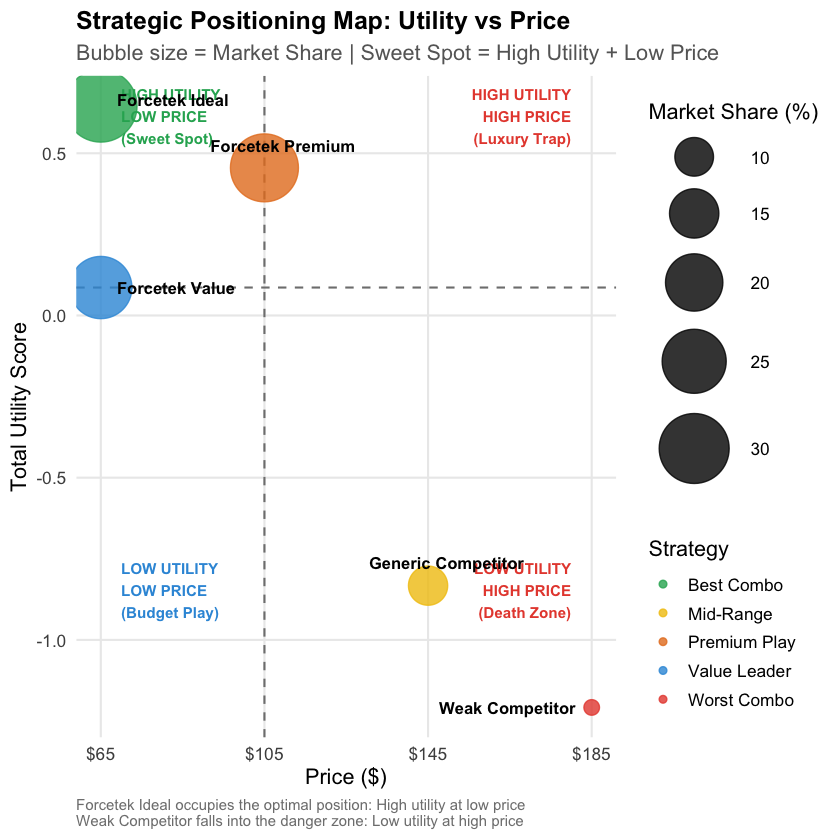

In [32]:
# A bubble chart showing where each product scenario sits
# in the Price x Utility space. Bubble size = Market Share.
# Quadrants reveal strategic zones.

# 1. Calculate average total utility per scenario (across respondents)
avg_total_utility <- colMeans(
  indiv_wide[, scenario_profiles$Scenario],
  na.rm = TRUE
)

# 2. Build the positioning data
positioning <- data.frame(
  Scenario = scenario_profiles$Scenario,
  Strategy_Type = scenario_profiles$Strategy_Type,
  Price_Code = scenario_profiles$A1,
  stringsAsFactors = FALSE
) %>%
  mutate(
    # Map price level codes to numeric values
    Price_Numeric = case_when(
      Price_Code == "A1L1" ~ 65,
      Price_Code == "A1L2" ~ 105,
      Price_Code == "A1L3" ~ 145,
      Price_Code == "A1L4" ~ 185
    ),
    Total_Utility = avg_total_utility
  ) %>%
  left_join(
    scenarios %>% select(Scenario, Market_Share),
    by = "Scenario"
  )

# Print positioning data
print("Strategic Positioning Data:")
print(positioning)

# 3. Calculate quadrant dividers (median price & median utility)
price_mid <- median(positioning$Price_Numeric)
utility_mid <- median(positioning$Total_Utility)

# 4. Create the Bubble Chart
if (!require(ggrepel)) install.packages("ggrepel")
library(ggrepel)

ggplot(positioning, aes(x = Price_Numeric, y = Total_Utility)) +

  # Quadrant divider lines
  geom_hline(yintercept = utility_mid, linetype = "dashed", color = "gray50") +
  geom_vline(xintercept = price_mid, linetype = "dashed", color = "gray50") +

  # Quadrant zone labels
  annotate("text",
    x = 70, y = max(positioning$Total_Utility) * 0.95,
    label = "HIGH UTILITY\nLOW PRICE\n(Sweet Spot)",
    color = "#27AE60", fontface = "bold", size = 3.2, hjust = 0
  ) +
  annotate("text",
    x = 180, y = max(positioning$Total_Utility) * 0.95,
    label = "HIGH UTILITY\nHIGH PRICE\n(Luxury Trap)",
    color = "#E74C3C", fontface = "bold", size = 3.2, hjust = 1
  ) +
  annotate("text",
    x = 70, y = min(positioning$Total_Utility) * 0.7,
    label = "LOW UTILITY\nLOW PRICE\n(Budget Play)",
    color = "#3498DB", fontface = "bold", size = 3.2, hjust = 0
  ) +
  annotate("text",
    x = 180, y = min(positioning$Total_Utility) * 0.7,
    label = "LOW UTILITY\nHIGH PRICE\n(Death Zone)",
    color = "#E74C3C", fontface = "bold", size = 3.2, hjust = 1
  ) +

  # Bubbles (size = market share)
  geom_point(
    aes(size = Market_Share, color = Strategy_Type),
    alpha = 0.8
  ) +

  # Scenario labels (repelled to avoid overlap)
  geom_text_repel(
    aes(label = Scenario),
    size = 3.5, fontface = "bold",
    box.padding = 0.6, point.padding = 0.5,
    max.overlaps = 10
  ) +

  # Scales
  scale_size_continuous(range = c(4, 20), name = "Market Share (%)") +
  scale_color_manual(
    values = c(
      "Best Combo" = "#27AE60",
      "Premium Play" = "#E67E22",
      "Value Leader" = "#3498DB",
      "Mid-Range" = "#F1C40F",
      "Worst Combo" = "#E74C3C"
    ),
    name = "Strategy"
  ) +
  scale_x_continuous(
    breaks = c(65, 105, 145, 185),
    labels = scales::dollar_format()
  ) +

  # Labels
  labs(
    title = "Strategic Positioning Map: Utility vs Price",
    subtitle = "Bubble size = Market Share | Sweet Spot = High Utility + Low Price",
    x = "Price ($)",
    y = "Total Utility Score",
    caption = paste0(
      positioning$Scenario[which.max(positioning$Market_Share)],
      " occupies the optimal position: High utility at low price\n",
      positioning$Scenario[which.min(positioning$Market_Share)],
      " falls into the danger zone: Low utility at high price"
    )
  ) +

  # Theme
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", size = 15),
    plot.subtitle = element_text(color = "gray40"),
    plot.caption = element_text(hjust = 0, color = "gray50", size = 9),
    panel.grid.minor = element_blank()
  )


